In [1]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
from matplotlib.backends.backend_pdf import PdfPages
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile

import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_Diagnostics as dt
import XSpect.XSpect_PostProcessing

Run 108 imported


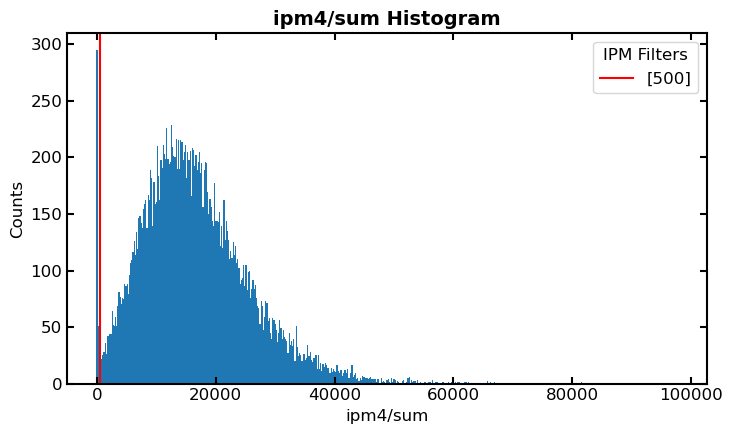

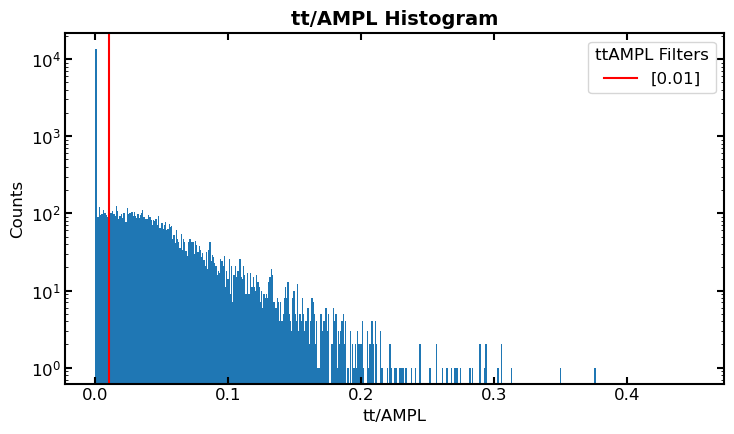

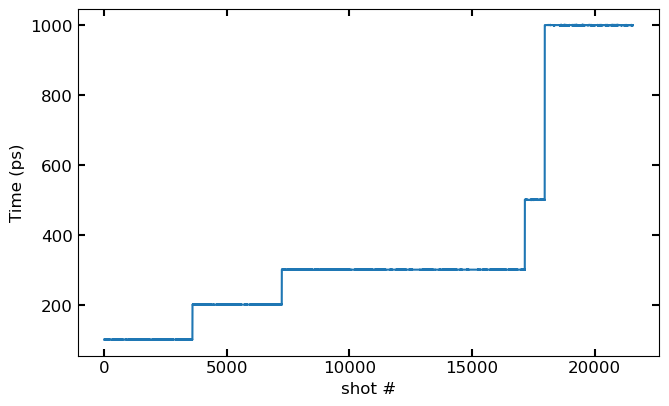

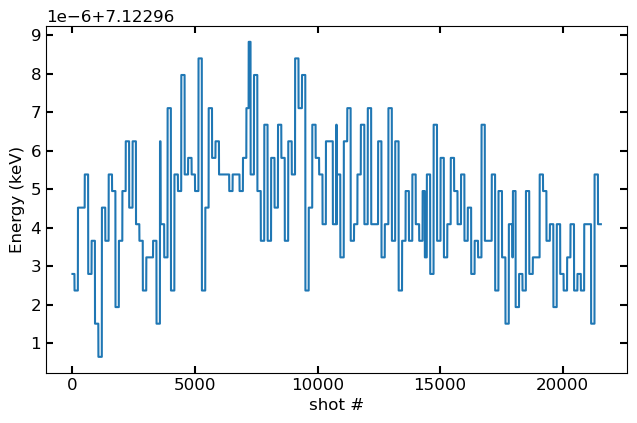

In [2]:
run = 108
exp = 'xcs101237825'
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl']

# pdf = PdfPages("output.pdf")

d = dt.diagnostics(run, exp, keys, names)

ipm_thres = [500]

d.ipm_histogram(ipm_thres)

# figx = plt.gcf()
# pdf.savefig(figx)

tt_thres = [0.01]

d.ttAMPL_histogram(tt_thres)

# d.droplet_histogram()

nshots = 1000

# adu_thres = [3.5]
# d.adu_histogram(nshots, adu_thres)

# ka_roi_d = [270, 300]
# kb_roi_d = [180, 220]

# d.detector_sum_ROI(ka_roi_d, kb_roi_d)

# ka_roi = [100, 120]
# kb_roi = [15, 55]

# d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 0)

# d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 1.4)

delay = d.h5[d.datadict['time_tool_correction']][:] + d.h5[d.datadict['lxt_ttc']][:]*1e12 + d.h5[d.datadict['encoder']][:]

plt.plot(delay)
plt.ylabel('Time (ps)')
# plt.ylim([0, 5])
plt.xlabel('shot #')
plt.show()

plt.plot(d.h5['epicsUser']['dccm_E'][:])
plt.xlabel('shot #')
plt.ylabel('Energy (keV)')
plt.show()

# pdf.close()

In [3]:
d.h5['scan'].keys()

<KeysViewHDF5 ['lxt_ttc', 'var0', 'varStep']>

In [4]:
scanlist = list(d.h5['scan'].keys())

motorname = [item for item in scanlist if 'var0' not in item]
motorname = [item for item in motorname if 'varStep' not in item]

In [5]:
motorname

['lxt_ttc']

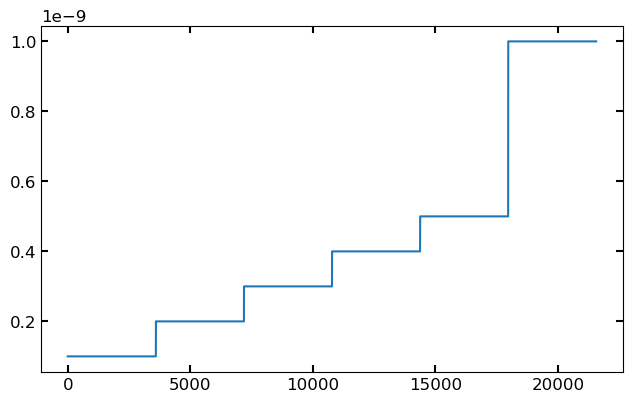

In [6]:
plt.plot(d.h5['scan']['var0'][:])

### XANES 1D Scanvar

In [15]:
start = time.time()

xspect_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(hutch='xcs',experiment_id=exp,lcls_run=exp[-2:])
xes1=XSpect.XSpect_Controller.ScanAnalysis_1D()
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL', 'epix_2/ROI_sum', 'scan/var0'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl', 'epix', 'scan']

#Here we define the epix detector keys separately as they are imported separately to avoid OOM
# xes1.key_epix=['epix_2/ROI_sum']
# xes1.friendly_name_epix=['epix']

##
xes1.set_key_aliases(keys,names)

xes1.transpose=False
xes1.add_filter('xray','ipm',500)
xes1.add_filter('simultaneous','ipm',500)
xes1.scattering = True

xes1.run_parser(['108-111']) # 1 ns

In [16]:
start=time.time()

xes1.primary_analysis_loop(xspect_experiment, verbose = True)

end=time.time()
print('Analysis completed: %.02f s' % (end - start))

Obtained shot properties
HDF5 import of keys completed. Time: 0.00 seconds
Shots (15286) combined for detector epix on filters: simultaneous and laser into epix_simultaneous_laser
Shots (6112) separated for detector epix on filters: xray and laser into epix_xray_not_laser
Shots (15286) combined for detector ipm on filters: simultaneous and laser into ipm_simultaneous_laser
Shots (6112) separated for detector ipm on filters: xray and laser into ipm_xray_not_laser
Shots (15286) combined for detector scan on filters: simultaneous and laser into scan_simultaneous_laser
Shots (6112) separated for detector scan on filters: xray and laser into scan_xray_not_laser
Shots (15286) combined for detector scanvar_indices on filters: simultaneous and laser into scanvar_indices_simultaneous_laser
Shots (6112) separated for detector scanvar_indices on filters: xray and laser into scanvar_indices_xray_not_laser
Detector epix_simultaneous_laser binned in energy into key: epix_simultaneous_laser_energy_bi

In [17]:
run_count = 0
for ii, run in enumerate(xes1.analyzed_runs):
    print(ii)
    # print(run.ccm_bins.shape)
    print(run.epix_simultaneous_laser_energy_binned.shape)
    print(run.epix_xray_not_laser_energy_binned.shape)
    run_count+=1

0
(7,)
(7,)
1
(7,)
(7,)
2
(7,)
(7,)
3
(7,)
(7,)


/lscratch/rribson/tmp/ipykernel_2422931/2797034222.py:8: RuntimeWarning: invalid value encountered in divide
  xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
/lscratch/rribson/tmp/ipykernel_2422931/2797034222.py:10: RuntimeWarning: invalid value encountered in divide
  xas_lon_norm = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned


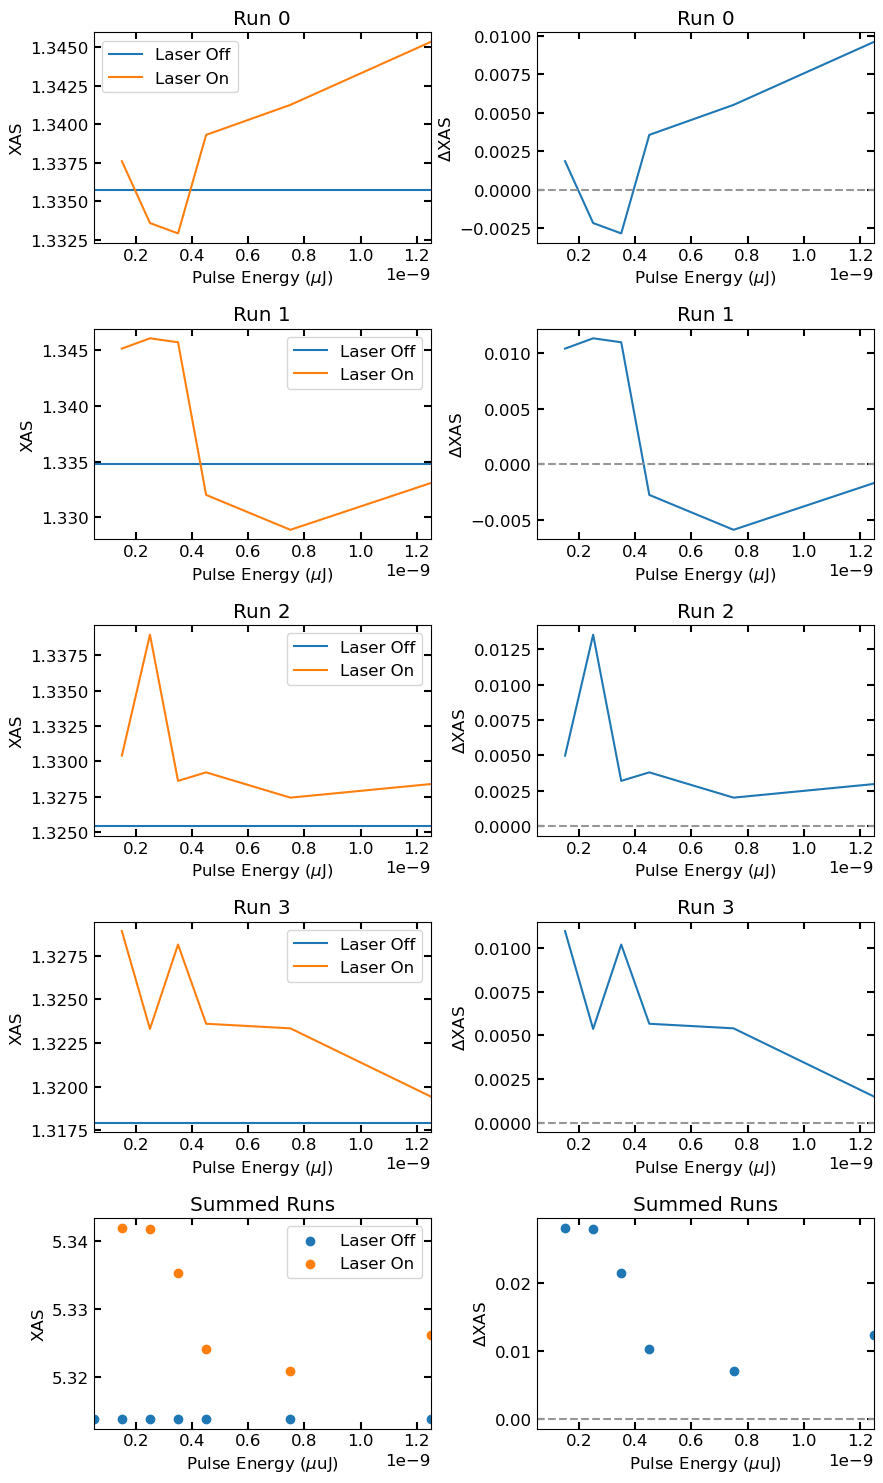

In [18]:
fig, ax = plt.subplots(figsize = (9,15), nrows = run_count+1, ncols = 2)
# fig, ax = plt.subplots(figsize = (9,8), nrows = 1, ncols = 2)

xas_loff_sum = np.zeros_like(xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned)
xas_lon_sum = np.zeros_like(xes1.analyzed_runs[0].epix_simultaneous_laser_energy_binned)

for ii, run in enumerate(xes1.analyzed_runs):
    xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
    xas_loff_norm_mean = np.ones_like(xas_loff_norm)*np.nanmean(xas_loff_norm)
    xas_lon_norm = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned
    xas_diff_norm = xas_lon_norm - xas_loff_norm_mean

    # if len(xes1.analyzed_runs) == 1:
    #     plt_indx0 = (0,)
    #     plt_indx1 = (1,)
    # elif len(xes1.analyzed_runs) > 1:
    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    ax[plt_indx0].plot(run.scanvar_bins, xas_loff_norm_mean, label = 'Laser Off')
    ax[plt_indx0].plot(run.scanvar_bins, xas_lon_norm, label = 'Laser On')
    ax[plt_indx0].set_xlim([np.min(run.scanvar_bins), np.max(run.scanvar_bins)])
    ax[plt_indx0].set_xlabel(r'Pulse Energy ($\mu$J)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)
    # ax[0].set_ylim([11, 13])

    ax[plt_indx1].plot(run.scanvar_bins, xas_diff_norm, label = 'Difference')
    ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
    ax[plt_indx1].set_xlim([np.min(run.scanvar_bins), np.max(run.scanvar_bins)])
    ax[plt_indx1].set_xlabel(r'Pulse Energy ($\mu$J)')
    ax[plt_indx1].set_ylabel(r'$\Delta$XAS')
    ax[plt_indx1].set_title('Run %i' % ii)
    # ax[1].axvline(14.45, color = 'r')
    # ax[plt_indx1].axvline(-.53, color = 'r')
    
    xas_loff_sum += xas_loff_norm
    xas_lon_sum += xas_lon_norm

xas_loff_sumtotal = np.ones_like(xas_loff_norm)*np.nanmean(xas_loff_sum)
xas_diff_sum = xas_lon_sum - xas_loff_sumtotal

plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

ax[plt_indx0_sum].scatter(run.scanvar_bins, xas_loff_sumtotal, label = 'Laser Off')
ax[plt_indx0_sum].scatter(run.scanvar_bins, xas_lon_sum, label = 'Laser On')
ax[plt_indx0_sum].set_xlim([np.min(run.scanvar_bins), np.max(run.scanvar_bins)])
ax[plt_indx0_sum].set_xlabel(r'Pulse Energy ($\mu$uJ)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Summed Runs')

ax[plt_indx1_sum].scatter(run.scanvar_bins, xas_diff_sum, label = 'Difference')
ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(run.scanvar_bins), np.max(run.scanvar_bins)])
ax[plt_indx1_sum].set_xlabel(r'Pulse Energy ($\mu$uJ)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Summed Runs')

plt.tight_layout()

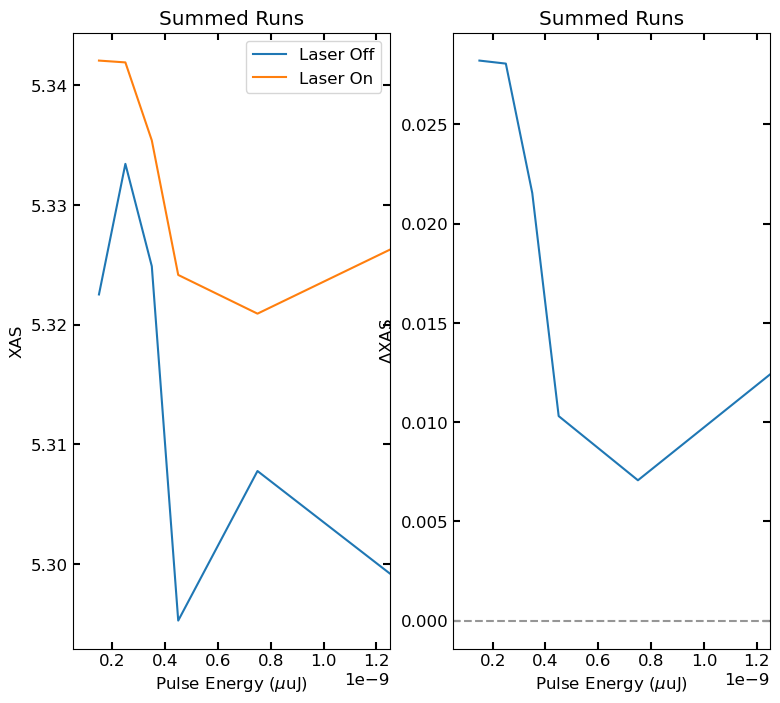

In [19]:
fig, ax = plt.subplots(figsize = (9,8), nrows = 1, ncols = 2)

plt_indx0_sum = (0,)
plt_indx1_sum = (1,)

ax[plt_indx0_sum].plot(run.scanvar_bins, xas_loff_sum, label = 'Laser Off')
ax[plt_indx0_sum].plot(run.scanvar_bins, xas_lon_sum, label = 'Laser On')
ax[plt_indx0_sum].set_xlim([np.min(run.scanvar_bins), np.max(run.scanvar_bins)])
ax[plt_indx0_sum].set_xlabel(r'Pulse Energy ($\mu$uJ)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Summed Runs')

ax[plt_indx1_sum].plot(run.scanvar_bins, xas_diff_sum, label = 'Difference')
ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(run.scanvar_bins), np.max(run.scanvar_bins)])
ax[plt_indx1_sum].set_xlabel(r'Pulse Energy ($\mu$uJ)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Summed Runs')
ax[plt_indx1_sum].axvline(14.425, color = 'r')
# ax[plt_indx1_sum].axvline(-.54, color = 'r')